# 🚀 AI Agent Benchmark v2.0

A comprehensive evaluation suite for CLI-based AI Agents (Gemini, Claude, Codex, etc.).

## 📈 Evolution from v1
This version introduces **complexity tiers** and **domain-specific challenges**:
1.  **Debugging (⭐):** Simple logic fixes.
2.  **Scripting (⭐⭐):** Regex and text processing.
3.  **Refactoring (⭐⭐):** Code quality and type safety.
4.  **Algorithms (⭐⭐⭐):** Logic and control flow (Pathfinding).
5.  **Data Science (⭐⭐⭐):** Library proficiency (Pandas).
6.  **Security (⭐⭐⭐⭐):** Vulnerability patching (SQL Injection).

## 📊 Scoring
- **Correctness (60%):** Pass/Fail on Unit Tests.
- **Code Quality (20%):** Linting score.
- **Efficiency (20%):** Weighted by diff size (penalizes unnecessary bloat).

---

In [1]:
!pip install pytest pylint pandas matplotlib seaborn flask -q
import os
import sys
import shutil
import subprocess
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from difflib import SequenceMatcher

# Setup Benchmark Directory
BENCHMARK_DIR = "tasks_v2"
if not os.path.exists(BENCHMARK_DIR):
    os.makedirs(BENCHMARK_DIR)
    
print(f"📂 Benchmark Workspace: {os.path.abspath(BENCHMARK_DIR)}")

📂 Benchmark Workspace: /Users/plawanrath/Documents/GitHub-public/deep-learning-sandbox/benchmarks/tasks_v2


In [2]:
class BenchmarkEngine:
    def __init__(self, base_dir):
        self.base_dir = base_dir
        self.results = []
        self.original_files = {}  # Store original file contents for diff calculation

    def create_task(self, task_name, files, extra_setup=None):
        task_path = os.path.join(self.base_dir, task_name)
        if os.path.exists(task_path):
            shutil.rmtree(task_path)
        os.makedirs(task_path)
        
        # Store original file contents for efficiency calculation
        self.original_files[task_name] = {}
        
        for fname, content in files.items():
            with open(os.path.join(task_path, fname), 'w') as f:
                f.write(content)
            # Save original content (only for non-test files)
            if not fname.startswith('test_'):
                self.original_files[task_name][fname] = content
                
        if extra_setup:
            extra_setup(task_path)
            
        print(f"\n🚀 TASK READY: {task_name}")
        print(f"👉 ACTION: cd {task_path} && <run_agent>")
        return task_path

    def _calculate_efficiency_score(self, task_name, task_path):
        """
        Calculate efficiency score (0-20) based on diff size.
        Smaller diffs = higher scores (rewards minimal, targeted changes).
        """
        if task_name not in self.original_files:
            return 20  # Default if no baseline
        
        total_lines_changed = 0
        
        for fname, original_content in self.original_files[task_name].items():
            file_path = os.path.join(task_path, fname)
            if not os.path.exists(file_path):
                continue
                
            with open(file_path, 'r') as f:
                modified_content = f.read()
            
            # Calculate diff using SequenceMatcher
            original_lines = original_content.splitlines()
            modified_lines = modified_content.splitlines()
            
            matcher = SequenceMatcher(None, original_lines, modified_lines)
            
            # Count changed lines (additions + deletions + modifications)
            for tag, i1, i2, j1, j2 in matcher.get_opcodes():
                if tag in ('replace', 'delete', 'insert'):
                    total_lines_changed += max(i2 - i1, j2 - j1)
        
        # Score inversely proportional to lines changed
        # 0-10 lines: 20 pts, 11-25: 15 pts, 26-50: 10 pts, 51-100: 5 pts, 100+: 0 pts
        if total_lines_changed <= 10:
            return 20
        elif total_lines_changed <= 25:
            return 15
        elif total_lines_changed <= 50:
            return 10
        elif total_lines_changed <= 100:
            return 5
        else:
            return 0

    def grade_task(self, task_name, agent_name):
        task_path = os.path.join(self.base_dir, task_name)
        print(f"📝 Grading {agent_name} on {task_name}...")
        
        # 1. Correctness (Pytest)
        try:
            proc = subprocess.run(['pytest', '.'], cwd=task_path, capture_output=True, text=True, timeout=15)
            tests_passed = proc.returncode == 0
            output = proc.stdout
        except Exception as e:
            tests_passed = False
            output = str(e)
            
        # 2. Code Quality (Pylint)
        lint_score = 0.0
        try:
            py_files = [f for f in os.listdir(task_path) if f.endswith('.py') and not f.startswith('test_')]
            if py_files:
                # Only grade the implementation file
                lint_proc = subprocess.run(['pylint', py_files[0], '--output-format=text'], 
                                         cwd=task_path, capture_output=True, text=True)
                match = re.search(r'rated at (-?[0-9.]+)/10', lint_proc.stdout)
                if match:
                    lint_score = float(match.group(1))
        except:
            pass
            
        # 3. Efficiency (Diff-based scoring)
        eff_score = self._calculate_efficiency_score(task_name, task_path)

        # Calculation (60/20/20 split)
        # Correctness: 0-60, Quality: 0-20, Efficiency: 0-20
        total = (100 if tests_passed else 0) * 0.6 + (max(0, lint_score) * 2) + eff_score
        
        res = {
            "Agent": agent_name,
            "Task": task_name,
            "Passed": tests_passed,
            "Quality": round(lint_score, 2),
            "Efficiency": eff_score,
            "Score": round(total, 2)
        }
        self.results.append(res)
        return pd.DataFrame([res])

    def revert_task(self, task_name, files):
        """
        Restore task files to original state for next agent.
        Ensures each agent starts from identical baseline.
        """
        task_path = os.path.join(self.base_dir, task_name)
        print(f"🔄 Reverting {task_name} to original state...")
        
        for fname, content in files.items():
            file_path = os.path.join(task_path, fname)
            with open(file_path, 'w') as f:
                f.write(content)
        
        print(f"✅ Task reset complete. Ready for next agent.")

engine = BenchmarkEngine(BENCHMARK_DIR)

## 🏗️ Task Definitions
We define the 6 tasks below. Run this cell to load the scenarios.

In [3]:
# --- TASK 1: DEBUGGING ---
task1_files = {
    "stats_util.py": """
def calculate_median(numbers):
    numbers.sort()
    n = len(numbers)
    return numbers[n // 2] # Bug: crashes on empty, wrong for even
""",
    "test_stats.py": """
import pytest
from stats_util import calculate_median
def test_median_odd(): assert calculate_median([1, 3, 5]) == 3
def test_median_even(): assert calculate_median([1, 2, 3, 4]) == 2.5
def test_empty(): assert calculate_median([]) is None
"""
}

# --- TASK 2: SCRIPTING ---
task2_files = {
    "log_parser.py": """
def parse_log_line(line):
    # Should return dict: {'timestamp':..., 'level':..., 'message':...}
    return None
""",
    "test_parser.py": """
from log_parser import parse_log_line
def test_valid():
    r = parse_log_line("[2023-01-01 10:00] INFO: msg")
    assert r['level'] == 'INFO' and r['message'] == 'msg'
def test_error():
    r = parse_log_line("[2023-01-01 10:00] ERROR: fail")
    assert r['level'] == 'ERROR'
def test_invalid():
    assert parse_log_line("garbage") is None
"""
}

# --- TASK 3: REFACTORING ---
task3_files = {
    "inventory.py": """
def p(d, i, q): # Poor naming
    if i in d: d[i] += q
    else: d[i] = q
    return d
""",
    "test_inventory.py": """
import inventory
def test_logic():
    d = {}
    # We look for 'p' or a renamed function 'update_inventory'
    func = getattr(inventory, 'update_inventory', inventory.p)
    func(d, 'item', 10)
    assert d['item'] == 10
"""
}

# --- TASK 4: ALGORITHMS (NEW) ---
task4_files = {
    "grid_search.py": """
def find_shortest_path(grid, start, end):
    # grid: 2D list, 0=empty, 1=wall
    # Return list of tuples [(r,c), ...] or None
    # TODO: Implement A* or BFS
    pass
""",
    "test_grid.py": """
from grid_search import find_shortest_path
def test_simple_path():
    grid = [[0, 0, 0], [1, 1, 0], [0, 0, 0]]
    path = find_shortest_path(grid, (0,0), (2,2))
    assert path is not None
    assert len(path) == 7 # Min steps for this S shape
def test_no_path():
    grid = [[0, 1, 0], [0, 1, 0], [0, 1, 0]]
    assert find_shortest_path(grid, (0,0), (0,2)) is None
"""
}

# --- TASK 5: DATA SCIENCE (NEW) ---
task5_files = {
    "sales_analysis.py": """
import pandas as pd
def analyze_revenue(csv_path):
    # 1. Load CSV (Date, Product, Revenue)
    # 2. Fill missing Revenue with Product mean
    # 3. Aggregate total Revenue by Month
    # Return pd.Series (Index=MonthStr, Value=Sum)
    pass
""",
    "test_sales.py": """
import pandas as pd
import os
from sales_analysis import analyze_revenue
def test_analysis():
    # Create dummy data
    df = pd.DataFrame({
        'Date': ['2023-01-01', '2023-01-15', '2023-02-01', '2023-02-20'],
        'Product': ['A', 'A', 'B', 'B'],
        'Revenue': [100, None, 200, 300] # Missing val should become 100
    })
    df.to_csv('sales.csv', index=False)
    res = analyze_revenue('sales.csv')
    assert res['2023-01'] == 200.0 # 100 + 100(filled)
    assert res['2023-02'] == 500.0
    os.remove('sales.csv')
"""
}

# --- TASK 6: SECURITY (NEW) ---
task6_files = {
    "auth_dao.py": """
import sqlite3
def get_user(db_path, username):
    conn = sqlite3.connect(db_path)
    c = conn.cursor()
    # VULNERABLE:
    query = f"SELECT id, user FROM users WHERE user = '{username}'"
    c.execute(query)
    return c.fetchone()
""",
    "test_security.py": """
import sqlite3, os
from auth_dao import get_user
def setup_module():
    conn = sqlite3.connect('test.db')
    conn.execute('CREATE TABLE users (id INT, user TEXT, pass TEXT)')
    conn.execute("INSERT INTO users VALUES (1, 'admin', 'secret')")
    conn.execute("INSERT INTO users VALUES (2, 'guest', '1234')")
    conn.commit()
    conn.close()
def teardown_module():
    if os.path.exists('test.db'): os.remove('test.db')
def test_normal_access():
    assert get_user('test.db', 'guest')[1] == 'guest'
def test_sql_injection():
    # This payload would return admin if vulnerable
    payload = "' OR '1'='1'"
    # If fixed, this should return None or match literally nothing
    res = get_user('test.db', payload)
    assert res is None
"""
}

---

## 🚦 Benchmark Execution Loop
We will now step through the tasks. 
**Instructions:**
1. Run the "SETUP" cell for a task.
2. Go to your terminal.
3. Run the Agent (Gemini/Claude/etc) to solve the task in the generated folder.
4. Come back here and run the "GRADE" cell.

### Task 01: Debugging (`stats_util.py`) ⭐

In [4]:
engine.create_task("01_debug", task1_files)


🚀 TASK READY: 01_debug
👉 ACTION: cd tasks_v2/01_debug && <run_agent>


'tasks_v2/01_debug'

#### 🛑 Gemini Agent

**STOP: Run Gemini now!**

Navigate to the task directory and run your agent:
```bash
cd tasks_v2/01_debug
# Run Gemini with prompt: "Fix all bugs in stats_util.py to make all tests pass"
```

When complete, run the GRADE cell below.

In [5]:
# GRADE Gemini
engine.grade_task("01_debug", "Gemini")

📝 Grading Gemini on 01_debug...


,Agent,Task,Passed,Quality,Efficiency,Score
0,Gemini,01_debug,True,6.25,20,92.5


In [6]:
# REVERT for next agent
engine.revert_task("01_debug", task1_files)

🔄 Reverting 01_debug to original state...
✅ Task reset complete. Ready for next agent.


#### 🛑 Claude Agent

**STOP: Run Claude now!**

Navigate to the task directory and run your agent:
```bash
cd tasks_v2/01_debug
# Run Claude with prompt: "Fix all bugs in stats_util.py to make all tests pass"
```

When complete, run the GRADE cell below.

In [7]:
# GRADE Claude
engine.grade_task("01_debug", "Claude")

📝 Grading Claude on 01_debug...


,Agent,Task,Passed,Quality,Efficiency,Score
0,Claude,01_debug,True,6.25,20,92.5


In [8]:
# REVERT for next agent
engine.revert_task("01_debug", task1_files)

🔄 Reverting 01_debug to original state...
✅ Task reset complete. Ready for next agent.


#### 🛑 Codex Agent

**STOP: Run Codex now!**

Navigate to the task directory and run your agent:
```bash
cd tasks_v2/01_debug
# Run Codex with prompt: "Fix all bugs in stats_util.py to make all tests pass"
```

When complete, run the GRADE cell below.

In [9]:
# GRADE Codex
engine.grade_task("01_debug", "Codex")

📝 Grading Codex on 01_debug...


,Agent,Task,Passed,Quality,Efficiency,Score
0,Codex,01_debug,True,8.89,15,92.78


### Task 02: Scripting (`log_parser.py`) ⭐⭐

In [10]:
engine.create_task("02_script", task2_files)


🚀 TASK READY: 02_script
👉 ACTION: cd tasks_v2/02_script && <run_agent>


'tasks_v2/02_script'

#### 🛑 Gemini Agent

**STOP: Run Gemini now!**

Navigate to the task directory and run your agent:
```bash
cd tasks_v2/02_script
# Run Gemini with prompt: "Implement the parse_log_line function to pass all tests"
```

When complete, run the GRADE cell below.

In [11]:
# GRADE Gemini
engine.grade_task("02_script", "Gemini")

📝 Grading Gemini on 02_script...


,Agent,Task,Passed,Quality,Efficiency,Score
0,Gemini,02_script,True,5.71,20,91.42


In [12]:
# REVERT for next agent
engine.revert_task("02_script", task2_files)

🔄 Reverting 02_script to original state...
✅ Task reset complete. Ready for next agent.


#### 🛑 Claude Agent

**STOP: Run Claude now!**

Navigate to the task directory and run your agent:
```bash
cd tasks_v2/02_script
# Run Claude with prompt: "Implement the parse_log_line function to pass all tests"
```

When complete, run the GRADE cell below.

In [13]:
# GRADE Claude
engine.grade_task("02_script", "Claude")

📝 Grading Claude on 02_script...


,Agent,Task,Passed,Quality,Efficiency,Score
0,Claude,02_script,True,7.14,20,94.28


In [14]:
# REVERT for next agent
engine.revert_task("02_script", task2_files)

🔄 Reverting 02_script to original state...
✅ Task reset complete. Ready for next agent.


#### 🛑 Codex Agent

**STOP: Run Codex now!**

Navigate to the task directory and run your agent:
```bash
cd tasks_v2/02_script
# Run Codex with prompt: "Implement the parse_log_line function to pass all tests"
```

When complete, run the GRADE cell below.

In [15]:
# GRADE Codex
engine.grade_task("02_script", "Codex")

📝 Grading Codex on 02_script...


,Agent,Task,Passed,Quality,Efficiency,Score
0,Codex,02_script,True,7.14,15,89.28


### Task 03: Refactoring (`inventory.py`) ⭐⭐

In [16]:
engine.create_task("03_refactor", task3_files)


🚀 TASK READY: 03_refactor
👉 ACTION: cd tasks_v2/03_refactor && <run_agent>


'tasks_v2/03_refactor'

#### 🛑 Gemini Agent

**STOP: Run Gemini now!**

Navigate to the task directory and run your agent:
```bash
cd tasks_v2/03_refactor
# Run Gemini with prompt: "Refactor the code to improve readability and maintainability while passing all tests"
```

When complete, run the GRADE cell below.

In [17]:
# GRADE Gemini
engine.grade_task("03_refactor", "Gemini")

📝 Grading Gemini on 03_refactor...


,Agent,Task,Passed,Quality,Efficiency,Score
0,Gemini,03_refactor,True,8.33,15,91.66


In [18]:
# REVERT for next agent
engine.revert_task("03_refactor", task3_files)

🔄 Reverting 03_refactor to original state...
✅ Task reset complete. Ready for next agent.


#### 🛑 Claude Agent

**STOP: Run Claude now!**

Navigate to the task directory and run your agent:
```bash
cd tasks_v2/03_refactor
# Run Claude with prompt: "Refactor the code to improve readability and maintainability while passing all tests"
```

When complete, run the GRADE cell below.

In [19]:
# GRADE Claude
engine.grade_task("03_refactor", "Claude")

📝 Grading Claude on 03_refactor...


,Agent,Task,Passed,Quality,Efficiency,Score
0,Claude,03_refactor,True,8.33,15,91.66


In [20]:
# REVERT for next agent
engine.revert_task("03_refactor", task3_files)

🔄 Reverting 03_refactor to original state...
✅ Task reset complete. Ready for next agent.


#### 🛑 Codex Agent

**STOP: Run Codex now!**

Navigate to the task directory and run your agent:
```bash
cd tasks_v2/03_refactor
# Run Codex with prompt: "Refactor the code to improve readability and maintainability while passing all tests"
```

When complete, run the GRADE cell below.

In [21]:
# GRADE Codex
engine.grade_task("03_refactor", "Codex")

📝 Grading Codex on 03_refactor...


,Agent,Task,Passed,Quality,Efficiency,Score
0,Codex,03_refactor,True,10.0,15,95.0


### Task 04: Algorithms (`grid_search.py`) ⭐⭐⭐

In [22]:
engine.create_task("04_algo", task4_files)


🚀 TASK READY: 04_algo
👉 ACTION: cd tasks_v2/04_algo && <run_agent>


'tasks_v2/04_algo'

#### 🛑 Gemini Agent

**STOP: Run Gemini now!**

Navigate to the task directory and run your agent:
```bash
cd tasks_v2/04_algo
# Run Gemini with prompt: "Implement the find_shortest_path function using BFS or A* to pass all tests"
```

When complete, run the GRADE cell below.

In [23]:
# GRADE Gemini
engine.grade_task("04_algo", "Gemini")

📝 Grading Gemini on 04_algo...


,Agent,Task,Passed,Quality,Efficiency,Score
0,Gemini,04_algo,True,5.83,10,81.66


In [24]:
# REVERT for next agent
engine.revert_task("04_algo", task4_files)

🔄 Reverting 04_algo to original state...
✅ Task reset complete. Ready for next agent.


#### 🛑 Claude Agent

**STOP: Run Claude now!**

Navigate to the task directory and run your agent:
```bash
cd tasks_v2/04_algo
# Run Claude with prompt: "Implement the find_shortest_path function using BFS or A* to pass all tests"
```

When complete, run the GRADE cell below.

In [25]:
# GRADE Claude
engine.grade_task("04_algo", "Claude")

📝 Grading Claude on 04_algo...


,Agent,Task,Passed,Quality,Efficiency,Score
0,Claude,04_algo,True,8.26,10,86.52


In [26]:
# REVERT for next agent
engine.revert_task("04_algo", task4_files)

🔄 Reverting 04_algo to original state...
✅ Task reset complete. Ready for next agent.


#### 🛑 Codex Agent

**STOP: Run Codex now!**

Navigate to the task directory and run your agent:
```bash
cd tasks_v2/04_algo
# Run Codex with prompt: "Implement the find_shortest_path function using BFS or A* to pass all tests"
```

When complete, run the GRADE cell below.

In [27]:
# GRADE Codex
engine.grade_task("04_algo", "Codex")

📝 Grading Codex on 04_algo...


,Agent,Task,Passed,Quality,Efficiency,Score
0,Codex,04_algo,True,8.65,10,87.3


### Task 05: Data Science (`sales_analysis.py`) ⭐⭐⭐

In [28]:
engine.create_task("05_data", task5_files)


🚀 TASK READY: 05_data
👉 ACTION: cd tasks_v2/05_data && <run_agent>


'tasks_v2/05_data'

#### 🛑 Gemini Agent

**STOP: Run Gemini now!**

Navigate to the task directory and run your agent:
```bash
cd tasks_v2/05_data
# Run Gemini with prompt: "Complete the analyze_revenue function to pass all tests"
```

When complete, run the GRADE cell below.

In [29]:
# GRADE Gemini
engine.grade_task("05_data", "Gemini")

📝 Grading Gemini on 05_data...


,Agent,Task,Passed,Quality,Efficiency,Score
0,Gemini,05_data,True,2.5,15,80.0


In [30]:
# REVERT for next agent
engine.revert_task("05_data", task5_files)

🔄 Reverting 05_data to original state...
✅ Task reset complete. Ready for next agent.


#### 🛑 Claude Agent

**STOP: Run Claude now!**

Navigate to the task directory and run your agent:
```bash
cd tasks_v2/05_data
# Run Claude with prompt: "Complete the analyze_revenue function to pass all tests"
```

When complete, run the GRADE cell below.

In [31]:
# GRADE Claude
engine.grade_task("05_data", "Claude")

📝 Grading Claude on 05_data...


,Agent,Task,Passed,Quality,Efficiency,Score
0,Claude,05_data,True,6.67,20,93.34


In [32]:
# REVERT for next agent
engine.revert_task("05_data", task5_files)

🔄 Reverting 05_data to original state...
✅ Task reset complete. Ready for next agent.


#### 🛑 Codex Agent

**STOP: Run Codex now!**

Navigate to the task directory and run your agent:
```bash
cd tasks_v2/05_data
# Run Codex with prompt: "Complete the analyze_revenue function to pass all tests"
```

When complete, run the GRADE cell below.

In [33]:
# GRADE Codex
engine.grade_task("05_data", "Codex")

📝 Grading Codex on 05_data...


,Agent,Task,Passed,Quality,Efficiency,Score
0,Codex,05_data,True,7.5,15,90.0


### Task 06: Security (`auth_dao.py`) ⭐⭐⭐⭐

In [34]:
engine.create_task("06_security", task6_files)


🚀 TASK READY: 06_security
👉 ACTION: cd tasks_v2/06_security && <run_agent>


'tasks_v2/06_security'

#### 🛑 Gemini Agent

**STOP: Run Gemini now!**

Navigate to the task directory and run your agent:
```bash
cd tasks_v2/06_security
# Run Gemini with prompt: "Fix the SQL injection vulnerability in get_user function to pass all tests"
```

When complete, run the GRADE cell below.

In [35]:
# GRADE Gemini
engine.grade_task("06_security", "Gemini")

📝 Grading Gemini on 06_security...


,Agent,Task,Passed,Quality,Efficiency,Score
0,Gemini,06_security,True,7.14,20,94.28


In [36]:
# REVERT for next agent
engine.revert_task("06_security", task6_files)

🔄 Reverting 06_security to original state...
✅ Task reset complete. Ready for next agent.


#### 🛑 Claude Agent

**STOP: Run Claude now!**

Navigate to the task directory and run your agent:
```bash
cd tasks_v2/06_security
# Run Claude with prompt: "Fix the SQL injection vulnerability in get_user function to pass all tests"
```

When complete, run the GRADE cell below.

In [37]:
# GRADE Claude
engine.grade_task("06_security", "Claude")

📝 Grading Claude on 06_security...


,Agent,Task,Passed,Quality,Efficiency,Score
0,Claude,06_security,True,7.14,20,94.28


In [38]:
# REVERT for next agent
engine.revert_task("06_security", task6_files)

🔄 Reverting 06_security to original state...
✅ Task reset complete. Ready for next agent.


#### 🛑 Codex Agent

**STOP: Run Codex now!**

Navigate to the task directory and run your agent:
```bash
cd tasks_v2/06_security
# Run Codex with prompt: "Fix the SQL injection vulnerability in get_user function to pass all tests"
```

When complete, run the GRADE cell below.

In [39]:
# GRADE Codex
engine.grade_task("06_security", "Codex")

📝 Grading Codex on 06_security...


,Agent,Task,Passed,Quality,Efficiency,Score
0,Codex,06_security,True,8.33,20,96.66


## 📈 Final Analysis

Summary Table:


,Agent,Task,Passed,Quality,Efficiency,Score
0,Gemini,01_debug,True,6.25,20,92.50
1,Claude,01_debug,True,6.25,20,92.50
2,Codex,01_debug,True,8.89,15,92.78
3,Gemini,02_script,True,5.71,20,91.42
4,Claude,02_script,True,7.14,20,94.28
5,Codex,02_script,True,7.14,15,89.28
6,Gemini,03_refactor,True,8.33,15,91.66
7,Claude,03_refactor,True,8.33,15,91.66
8,Codex,03_refactor,True,10.00,15,95.00
9,Gemini,04_algo,True,5.83,10,81.66


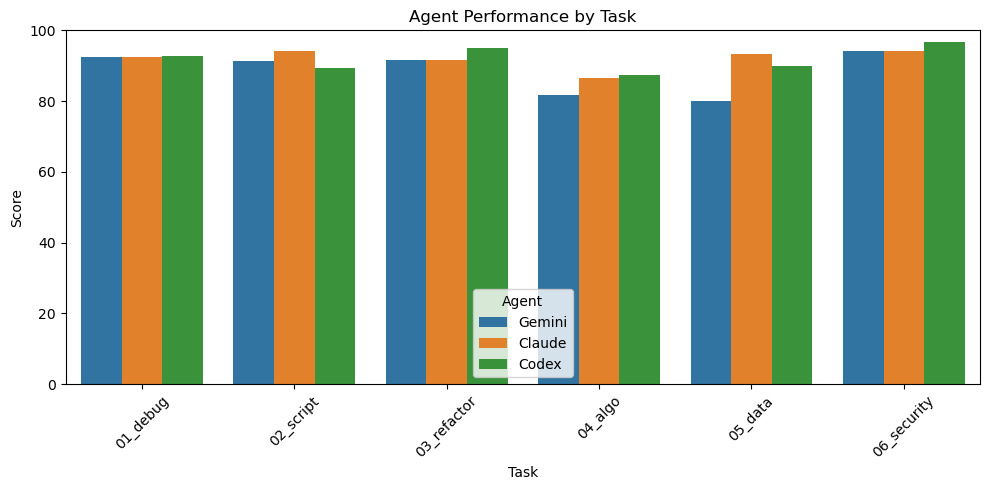

In [40]:
if engine.results:
    df = pd.DataFrame(engine.results)
    print("Summary Table:")
    display(df)
    
    # Visualization
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df, x='Task', y='Score', hue='Agent')
    plt.title("Agent Performance by Task")
    plt.ylim(0, 100)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No results to analyze.")